# Building an End-to-End Image Classifier with CNNs.

# Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:


• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [202]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/sem6-AIandML/worksheet5/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/sem6-AIandML/worksheet5/FruitinAmazon/test"
# Define image size
img_height, img_width = 28, 28

In [203]:
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    for label, cls in enumerate(class_names):
        class_path = os.path.join(folder, cls)
        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            try:
                img = Image.open(img_path).convert("L").resize((img_height, img_width))
                images.append(np.array(img) / 255.0)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")


Training set: (90, 28, 28, 1), Labels: (90, 6)
Testing set: (30, 28, 28, 1), Labels: (30, 6)


In [204]:
# Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Print each class and its contents
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    files = os.listdir(class_path)

    print(f"\nClass: {cls}")
    print(f"Number of images: {len(files)}")


Class: guarana
Number of images: 15

Class: cupuacu
Number of images: 15

Class: pupunha
Number of images: 15

Class: acai
Number of images: 15

Class: tucuma
Number of images: 15

Class: graviola
Number of images: 15


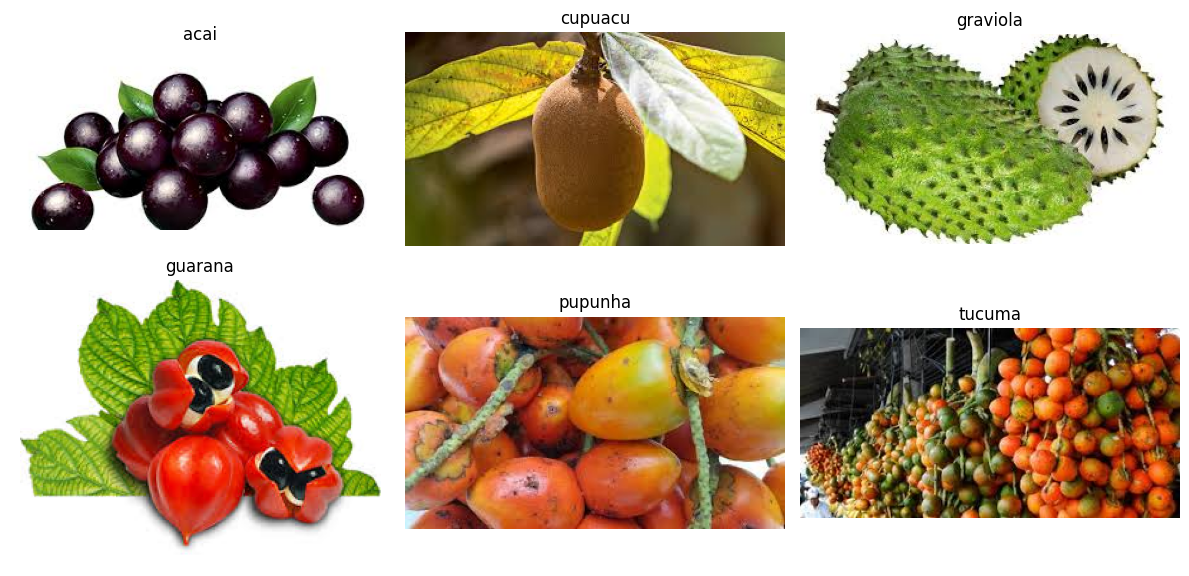

In [205]:
import random
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg'))]

    img_name = random.choice(files)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    images.append(img)
    labels.append(cls)

num_images = len(images)
cols = (num_images + 1) // 2

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Dataset size is small but balanced with 6 classes of fruits and 15 images per class. It's a very small dataset, so
overfitting is a major risk

So:

Training set = 90 images total

Testing set = 30 images total

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

• Hint:

– Iterate through each class subdirectory and check if each image is valid.


– Use the Image.open() function to attempt to load each image.

– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".

– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.

In [206]:
corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Iterate through images in class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening the image
            img = Image.open(img_path)
            img.verify()  # checks if image is corrupted

        except (IOError, SyntaxError):
            # Remove corrupted image
            os.remove(img_path)
            corrupted_images.append(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras:

In this section, we will load and preprocess image data from a directory using the **image_dataset_from_directory** function in Keras.

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.

In [207]:
# Define parameters
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

# Normalization layer (scales pixel values to [0, 1])
rescale = tf.keras.layers.Rescaling(1/255)

# Train Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN with

Follow the following Structure and Hyper - parameters:


**Convolutional Architecture:**


**• Convolutional Layer 1:**

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

**• Activation Layer:** ReLU activation

**• Pooling Layer 1:** Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2


**• Convolutional Layer 2:**


– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1


**• Activation Layer:** ReLU activation

**• Pooling Layer 2:** Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2


Fully Connected Network Architecture:


**• Flatten Layer:** Flatten the input coming from the convolutional layers

**• Input Layer:**

**• Hidden Layer - 2:**

– Number of Neurons: 64

– Number of Neurons: 128


**• Output Layer:**

– Number of Neurons: num classes (number of output classes)

In [208]:

from tensorflow.keras import layers, models

# Hyper-parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
SEED = 123

# Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
# Load test set
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

# get class name
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


# Normalize data
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))




Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [209]:
# Build CNN
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Convo block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convo block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),

    #fully connected neural network
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [210]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 5: Train the Model

**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [211]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

EPOCHES = 250

# Callback to model with highest accuracy
checkpoint_cb = ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

# Callback to model when loss stops decreasing
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    # min_delta=0.001,
    restore_best_weights=True,
    verbose=1,
)

# Train the model wiht all configurations
history = model.fit(
    train_ds,
    epochs=EPOCHES,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.2257 - loss: 2.7893
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - accuracy: 0.1806 - loss: 3.0147 - val_accuracy: 0.1667 - val_loss: 1.6134
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.1997 - loss: 1.8757
Epoch 2: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.1806 - loss: 1.8692 - val_accuracy: 0.0000e+00 - val_loss: 1.8522
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.3434 - loss: 1.7343
Epoch 3: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.3472 - loss: 1.7202 - val_accuracy: 0.0000e+00 - val_loss: 1.7851
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.3281 - loss: 1.6209
Epoch 4: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.3333 - loss: 1.6102 - val_accuracy: 0.1111 - val_loss: 1.6466
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5910 - los


Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.6111 - loss: 1.3551 - val_accuracy: 0.4444 - val_loss: 1.5189
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5639 - loss: 1.1847
Epoch 6: val_accuracy improved from 0.44444 to 0.77778, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - accuracy: 0.6111 - loss: 1.1365 - val_accuracy: 0.7778 - val_loss: 0.9512
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9240 - loss: 0.6974
Epoch 7: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.8750 - loss: 0.7368 - val_accuracy: 0.7778 - val_loss: 0.7138
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9118 - loss: 0.4695
Epoch 8: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - accuracy: 0.9028 - loss: 0.4481 - val_accuracy: 0.7222 - val_loss: 0.9438
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8837 - loss: 0.2715
Epoch 9: val_accuracy improved from 0.77778 to 0.88889, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.9028 - loss: 0.2462 - val_accuracy: 0.8889 - val_loss: 0.3446
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9097 - loss: 0.2264
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.9028 - loss: 0.2233 - val_accuracy: 0.7778 - val_loss: 0.7053
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9510 - loss: 0.1681
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.9583 - loss: 0.1420 - val_accuracy: 0.8333 - val_loss: 0.4412
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9941 - loss: 0.0410
Epoch 12: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.9861 - loss: 0.0541 - val_accuracy: 0.9444 - val_loss: 0.3180
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 1.0000 - loss: 0.0181
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 1.0000 - loss: 0.0189 - val_accuracy: 0.7778 - val_loss: 0.5233
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 1.0000 - loss: 0.0152
Epoch 14: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.8333 - val_loss: 0.5698
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.0058
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.8333 - val_loss: 0.4869
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 1.0000 - los

# Task 6: Evaluate the Model

**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [212]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6667 - loss: 0.7876

Test Loss:     0.7876
Test Accuracy: 0.6667


# Task 7: Save and Load the Model

**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [213]:
# Save
model.save('fruit_cnn_model.h5')
print('Model saved as fruit_cnn_model.h5')

# Load and re-evaluate
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f'Loaded model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}')

Model saved as fruit_cnn_model.h5


Loaded model — Test Loss: 0.7876 | Test Accuracy: 0.6667


**Task 7: Predictions and Classification Report**

**Making Predictions**


• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the
Classification Report of your Model Performance.

In [214]:
from sklearn.metrics import classification_report

y_true, y_pred = [], []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('Classification Report')
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.71      1.00      0.83         5
      tucuma       0.33      0.20      0.25         5

    accuracy                           0.67        30
   macro avg       0.68      0.67      0.64        30
weighted avg       0.68      0.67      0.64        30

